In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [7]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [8]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [9]:
df.drop(columns = ['RowNumber','CustomerId','Surname'] , inplace= True)

In [10]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
df =pd.get_dummies(df , columns=['Geography','Gender'] ,dtype=int, drop_first = True)

In [12]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [13]:
X = df.drop(columns = ['Exited'])
y = df['Exited']

from sklearn.model_selection import train_test_split
X_train,X_test, y_train , y_test = train_test_split(X,y,test_size= 0.2, random_state = 1)

In [14]:
X_train.shape

(8000, 11)

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [16]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [17]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential()

# model.add(Dense(3,activation='sigmoid',input_dim = 11))
# model.add(Dense(1,activation='sigmoid'))

model.add(Dense(11,activation='relu',input_dim = 11))
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))


# 00/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8223 - loss: 0.4125 - val_accuracy: 0.8188 - val_loss: 0.4191
# Epoch 9/100
# 200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8248 - loss: 0.4083 - val_accuracy: 0.8238 - val_loss: 0.4161
# Epoch 10/100
# 200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8302 - loss: 0.4044 - val_accuracy: 0.8263 - val_loss: 0.4112
# Epoch 11/100
# 200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8344 - loss: 0.3992 - val_accuracy: 0.8263 - val_loss: 0.4065
# Epoch 12/100
# 200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8408 - loss: 0.3928 - val_accuracy: 0.8331 - val_loss: 0.3985
# Epoch 13/100
# ...
# Epoch 99/100
# 200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8678 - loss: 0.3201 - val_accuracy: 0.8525 - val_loss: 0.3549
# Epoch 100/100
# 200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8687 - loss: 0.3195 - val_accuracy: 0.8550 - val_loss: 0.3542
# Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-08-30 13:41:24.793501: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(loss = 'binary_crossentropy', optimizer = 'Adam' , metrics=['accuracy'])


In [21]:
history = model.fit(X_train_scaled , y_train , epochs = 100 , validation_split=0.2 )

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7445 - loss: 0.5754 - val_accuracy: 0.7975 - val_loss: 0.5011
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7972 - loss: 0.4703 - val_accuracy: 0.7975 - val_loss: 0.4569
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8005 - loss: 0.4420 - val_accuracy: 0.8131 - val_loss: 0.4420
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8084 - loss: 0.4302 - val_accuracy: 0.8119 - val_loss: 0.4354
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8109 - loss: 0.4245 - val_accuracy: 0.8156 - val_loss: 0.4292
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8164 - loss: 0.4201 - val_accuracy: 0.8144 - val_loss: 0.4255
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8175 - loss: 0.4160 - val_accuracy: 0.8169 - val_loss: 0.4237
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8223 - loss: 0.4125 - val_accu

In [22]:
model.layers[0].get_weights()

[array([[-0.35848805,  0.21650022, -0.2063828 ,  0.11802716, -0.36709064,
          0.10996817, -0.2740555 ,  0.02083987,  0.10825407, -0.07455463,
          0.19329536],
        [-0.4361493 , -0.5788589 ,  0.29785797, -0.5819096 , -0.19008036,
          0.01571479, -1.099196  ,  0.40486172, -1.1637598 ,  0.45389962,
          0.10454535],
        [-0.2808485 ,  0.11544655,  0.6607643 , -0.3855471 ,  0.4242929 ,
         -0.04934851,  0.16418643,  0.05042239, -0.30363476,  0.06188154,
         -0.23978913],
        [ 0.5837472 , -0.06323455, -0.35707718, -0.98629355,  0.18947667,
         -0.9378239 , -0.25928718,  0.1678022 ,  0.19468664, -0.43803197,
          0.00668797],
        [-0.31680202, -0.37386146,  0.34204426, -0.18493275,  0.72140497,
         -0.1371293 , -0.09271388, -0.3238103 , -0.29453653, -1.4722315 ,
          1.0324749 ],
        [ 0.0364257 ,  0.05376851,  0.20422502, -0.07206734,  0.0717092 ,
          0.05534265,  0.18434773,  0.40708068,  0.02672636,  0.1089573

In [23]:
model.layers[1].get_weights()

[array([[ 0.48010662,  0.696894  , -0.25648406,  0.35254046,  0.0020881 ,
         -0.12988102, -0.2609101 , -0.00598056, -0.39578238,  0.5187213 ,
         -0.3041655 ],
        [ 0.36630467,  0.31002292, -1.3001574 ,  0.4692743 ,  0.459882  ,
         -0.38950416, -0.19762486, -0.29793257,  0.44099972,  0.43542182,
         -0.52738744],
        [-0.33123824,  0.06636392,  0.0416898 ,  0.3740618 ,  0.3643878 ,
         -0.17890167,  0.6590323 , -0.15291293,  0.3311349 ,  0.48048598,
          0.1790931 ],
        [-0.06898029,  0.38978186, -0.64247733,  0.04034615,  0.47467187,
          0.79751194,  0.45269036,  0.24651794,  0.17305703,  0.27575997,
         -0.6309803 ],
        [-0.06494518, -0.26196426, -0.7202479 ,  0.12379421,  0.01286157,
         -0.39091825, -0.21405385,  0.776655  ,  0.08549066, -0.12344635,
          0.34357345],
        [ 0.811097  ,  0.21092871, -0.35533378,  0.44878432,  0.26336423,
          0.55889094,  0.7438927 , -0.17506237, -0.00659035,  0.3133571

In [24]:
model.layers[2].get_weights()

[array([[-1.0693647 ],
        [ 0.7495874 ],
        [-1.3562907 ],
        [-1.2874492 ],
        [-0.23423608],
        [-0.32639414],
        [-0.539055  ],
        [ 1.3807884 ],
        [ 0.62822104],
        [-0.57012504],
        [ 1.8050764 ]], dtype=float32),
 array([0.01180045], dtype=float32)]

In [25]:
y_log= model.predict(X_test_scaled)   # output is probablity so we will convert it into 0 and 1 by deciding a threshold

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [26]:
y_pred = np.where(y_log >0.5, 1 , 0)

In [27]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [28]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8665

## To increase accuracy 
1. we can increase number of nodes in hidden layer .
2. choose a good activation function like reLU .
3. Increase number of epoch

In [29]:
import matplotlib.pyplot as plt


In [30]:
history.history

{'accuracy': [0.7445312738418579,
  0.7971875071525574,
  0.8004687428474426,
  0.8084375262260437,
  0.8109375238418579,
  0.81640625,
  0.8174999952316284,
  0.8223437666893005,
  0.8248437643051147,
  0.8301562666893005,
  0.8343750238418579,
  0.8407812714576721,
  0.8423437476158142,
  0.8457812666893005,
  0.8470312356948853,
  0.8506249785423279,
  0.8521875143051147,
  0.8548437356948853,
  0.8557812571525574,
  0.8570312261581421,
  0.8573437333106995,
  0.8578125238418579,
  0.8617187738418579,
  0.8604687452316284,
  0.8595312237739563,
  0.8603125214576721,
  0.8600000143051147,
  0.8612499833106995,
  0.8603125214576721,
  0.8615624904632568,
  0.8618749976158142,
  0.8614062666893005,
  0.8615624904632568,
  0.86328125,
  0.8621875047683716,
  0.8626562356948853,
  0.8615624904632568,
  0.862500011920929,
  0.8617187738418579,
  0.8646875023841858,
  0.8626562356948853,
  0.8628125190734863,
  0.86328125,
  0.864062488079071,
  0.8628125190734863,
  0.8623437285423279,
  

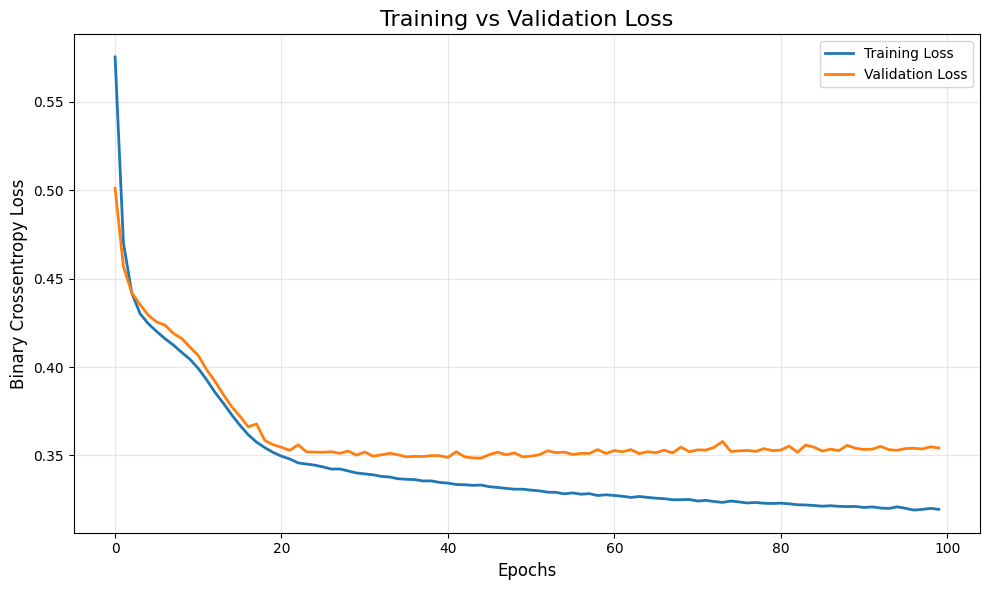

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)

plt.title('Training vs Validation Loss', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Binary Crossentropy Loss', fontsize=12)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

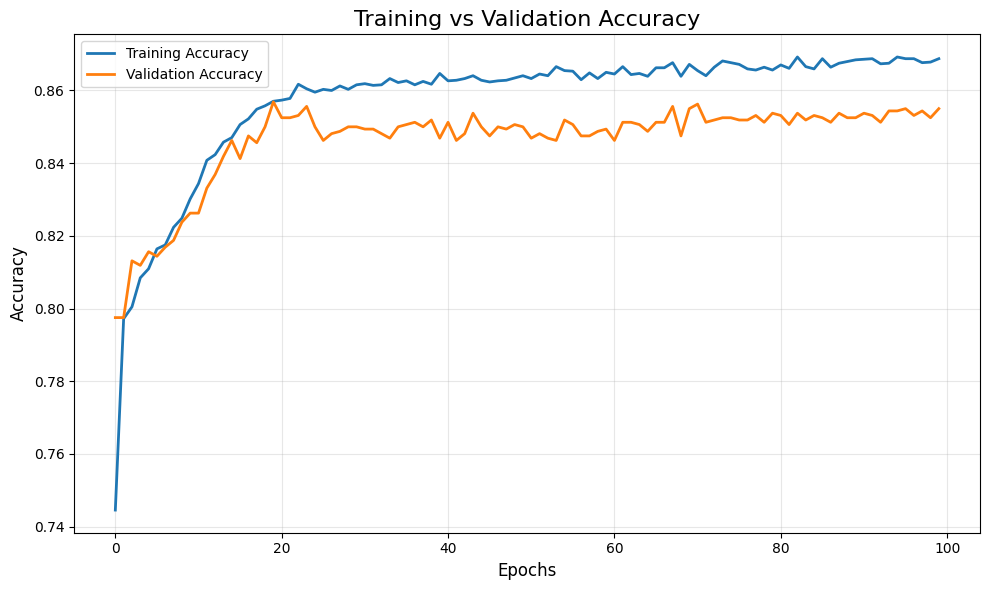

In [32]:
plt.figure(figsize=(10, 6))

plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)

plt.title('Training vs Validation Accuracy', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()